<a href="https://colab.research.google.com/github/deartoms/python/blob/main/Outlier%EC%9D%B4%EC%83%81%EC%B9%98%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 환경설정

In [1]:
# 구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

# 드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt # 그래프를 그리는 모듈
import matplotlib.font_manager as fm # 폰트를 관리하는 모듈

# 드라이브 내 폰트 경로
font_path = '/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family='NanumGothic') # matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스(-) 기호가 깨지지 않도록 유니코드 마이너스 비활성화

print("현재 폰트: ", plt.rcParams['font.family']) # 현재 적용된 폰트 이름 출력

Mounted at /content/drive
현재 폰트:  ['NanumGothic']


In [3]:
import pandas as pd # 데이터프레임 조작
import numpy as np # 수치 계산 및 NaN 처리
import matplotlib.pyplot as plt # 그래프 시각화
import seaborn as sns # 통계 시각화

# 타이타닉 데이터 로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu/bigdata/dataPreProcessing/train.csv')
print(titanic.shape)
titanic.tail()

(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [8]:
titanic_clean = titanic.copy()

# Cabin 열 삭제
titanic_clean = titanic_clean.drop(columns=['Cabin'])

# Age 결측치 처리
titanic_clean['Age'] = titanic_clean.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked 결측치 처리
titanic_clean['Embarked'] = titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)

# 최종 결측치 현황 확인
print("전처리 후 결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n 원본 shape: {titanic.shape}")
print(f"전처리 후 shape: {titanic_clean.shape}")

전처리 후 결측치: 
Series([], dtype: int64)

 원본 shape: (891, 12)
전처리 후 shape: (891, 11)


In [9]:
from scipy import stats # 통계 연산 모듈, Z-score 계산, Q-Q Plot 등에 사용

print(titanic_clean[['Age', 'Fare']].describe()) # 기술 통계량 출력
# 이상치가 있으면: 평균 >> 중앙값(50%), 최대값이 75%값보다 극단적으로 큰 경우

              Age        Fare
count  891.000000  891.000000
mean    29.112424   32.204208
std     13.304424   49.693429
min      0.420000    0.000000
25%     21.500000    7.910400
50%     26.000000   14.454200
75%     36.000000   31.000000
max     80.000000  512.329200


실습 1. 시각화로 이상치 탐색

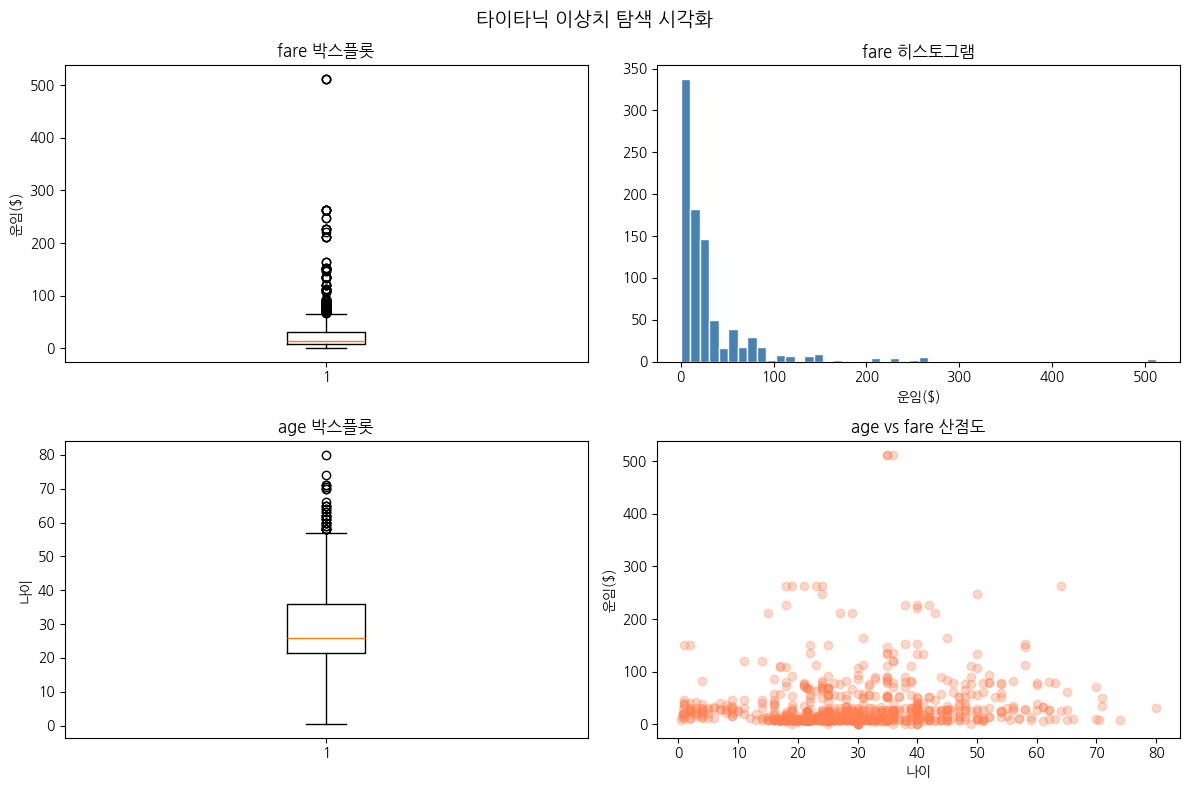

운임 상위 10개
[512.3292 512.3292 512.3292 263.     263.     263.     263.     262.375
 262.375  247.5208]


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # 2행x2열
fig.suptitle('타이타닉 이상치 탐색 시각화', fontsize=14)

# fare 박스플롯
axes[0, 0].boxplot(titanic_clean['Fare'].dropna())
axes[0, 0].set_title('fare 박스플롯')
axes[0, 0].set_ylabel('운임($)')

# fare 히스토그램
axes[0, 1].hist(titanic_clean['Fare'], bins=50, color='steelblue', edgecolor='white')
axes[0, 1].set_title('fare 히스토그램')
axes[0, 1].set_xlabel('운임($)')

# age 박스플롯
axes[1, 0].boxplot(titanic_clean['Age'].dropna())
axes[1, 0].set_title('age 박스플롯')
axes[1, 0].set_ylabel('나이')

# fare vs age 산점도
axes[1, 1].scatter(titanic_clean['Age'], titanic['Fare'], alpha=0.3, color='coral')
axes[1, 1].set_title('age vs fare 산점도')
axes[1, 1].set_xlabel('나이')
axes[1, 1].set_ylabel('운임($)')

plt.tight_layout()
plt.show()

print('운임 상위 10개')
print(titanic_clean['Fare'].nlargest(10).values)

### 실습 2. IQR 방법으로 이상치 탐지

In [17]:
# IQR(사분위 범위) 계산
Q1 = titanic_clean['Fare'].quantile(0.25)
Q3 = titanic_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR # 이상치 하한
upper_bound = Q3 + 1.5 * IQR # 이상치 상한

print(f"Q1: {Q1:.1f}")
print(f"Q3: {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"정상 범위: {lower_bound:.1f} ~ {upper_bound:.1f}")

# 이상치 마스킹
outlier_mask = (titanic_clean['Fare'] < lower_bound) | (titanic_clean['Fare'] > upper_bound)
outliers = titanic_clean[outlier_mask] # # 이상치 마스크가 True인 행만 추출

print("\n 이상치 승객 상위 5명")
print(outliers[['Pclass', 'Sex', 'Age', 'Fare', 'Survived']].head())

print(f"\n 이상치 개수: {outlier_mask.sum()}")
print(f"전체 대비 비율: {outlier_mask.mean()*100:.1f}%")

Q1: 7.9
Q3: 31.0
IQR: 23.1
정상 범위: -26.7 ~ 65.6

 이상치 승객 상위 5명
    Pclass     Sex   Age      Fare  Survived
1        1  female  38.0   71.2833         1
27       1    male  19.0  263.0000         0
31       1  female  35.0  146.5208         1
34       1    male  28.0   82.1708         0
52       1  female  49.0   76.7292         1

 이상치 개수: 116
전체 대비 비율: 13.0%


### 실습 3. Z-score 방법으로 이상치 탐지

In [19]:
# Z-score 계산
fare_zscore = stats.zscore(titanic_clean['Fare'].dropna()) ## NaN 제거 후 각 값의 Z-score 계산

# |Z| > 3 인 값을 이상치로 판단, 정규분포에서 |Z|>3은 전체의 약 0.3%에 해당하는 극단값
zscore_series = pd.Series(fare_zscore, index=titanic_clean['Fare'].dropna().index)
outlier_z_mask = zscore_series.abs() > 3 # Z-score 절댓값이 3 초과인 행을 이상치로 표시

print(f"Z-score 기준 이상치 수: {outlier_z_mask.sum()}")

# IQR vs Z-score 비교
fare_clean = titanic_clean[['Fare']].copy() # 새 DataFrame 생성
fare_clean['z_score'] = zscore_series
fare_clean['is_outlier_iqr'] = outlier_mask
fare_clean['is_outlier_zscore'] = outlier_z_mask

print('\n 두 방법 비교')
print(f"IQR 이상치: {outlier_mask.sum()}개")
print(f"Z-score 이상치: {outlier_z_mask.sum()}개")
print(f"두 방법 모두 이상치: {(outlier_mask & outlier_z_mask).sum()}")

Z-score 기준 이상치 수: 20

 두 방법 비교
IQR 이상치: 116개
Z-score 이상치: 20개
두 방법 모두 이상치: 20


### 실습 4. 이상치 시각화 - 탐지 결과 표시

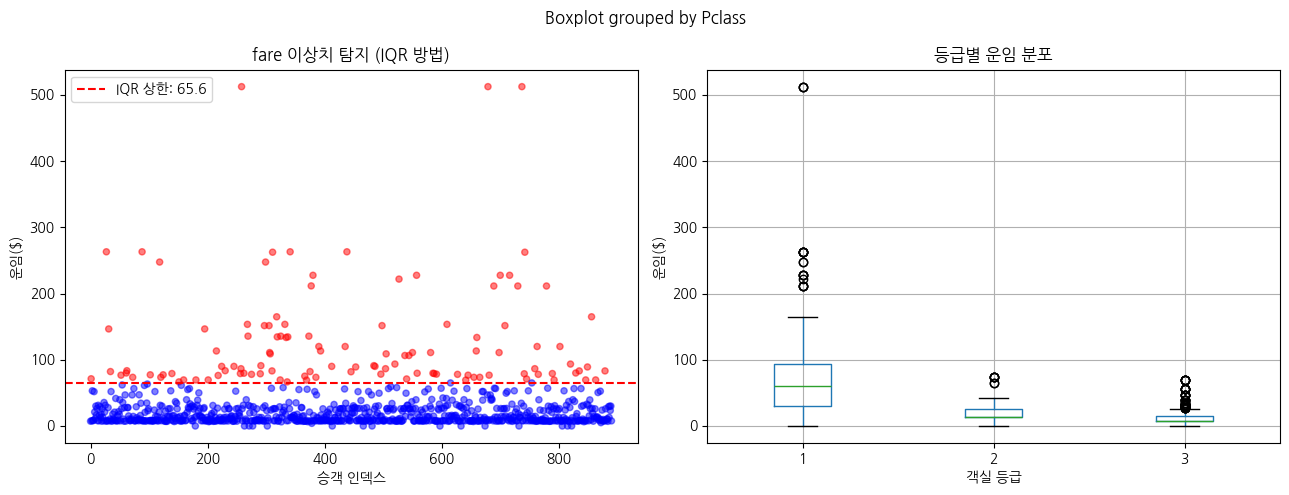

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5)) # 1x2 서브플롯 생성

# 공통 색상 설정: IQR 상한 초과면 빨강, 정상이면 파란색
colors = titanic_clean['Fare'].apply( # apply()로 행마다 람다 함수 적용
    lambda x: 'red' if x > upper_bound else 'blue'
)

# 이상치 강조 산점도
axes[0].scatter(range(len(titanic_clean)), titanic_clean['Fare'], c=colors, alpha=0.5, s=20) ##  x축-승객 인덱스(0~890), y축=운임, 점 크기
axes[0].axhline(y=upper_bound, color='red', linestyle='--', label=f'IQR 상한: {upper_bound:.1f}') #이 선 위
axes[0].set_title('fare 이상치 탐지 (IQR 방법)')
axes[0].set_xlabel('승객 인덱스')
axes[0].set_ylabel('운임($)')
axes[0].legend()

# 등급별 박스플롯 (그룹 비교)
titanic_clean.boxplot(column='Fare', by='Pclass', ax=axes[1]) # Pc class(객실 등급)별로 Fare 분포를 박스플롯
axes[1].set_title('등급별 운임 분포')
axes[1].set_xlabel('객실 등급')
axes[1].set_ylabel('운임($)')

# plt.suptitle('') # 상단 제목을 빈 문자열로
plt.tight_layout()
plt.show()

### 실습 5. 이상치 처리 -- 제거 (Drop)

In [22]:
# 이상치 제거
titanic_no_outlier = titanic[~outlier_mask].copy() # ~outlier_mask: 이상치 마스크를 반전(NOT 연산), 정상치

print(f"원본 행 수: {len(titanic_clean)}")
print(f"이상치 제거 후: {len(titanic_no_outlier)}") # 정상 데이터만

# 제거 전후 fare 통계 비교
comparison = pd.DataFrame({
    '원본' : titanic_clean['Fare'].describe(),
    '이상치 제거': titanic_no_outlier['Fare'].describe()
}).round(2)
display(comparison)

원본 행 수: 891
이상치 제거 후: 775


,원본,이상치 제거
count,891.00,775.00
mean,32.20,17.82
std,49.69,13.58
min,0.00,0.00
25%,7.91,7.90
50%,14.45,13.00
75%,31.00,26.00
max,512.33,65.00


### 실습 6. 이상치 처리 -- 캡핑(Clipping)

캡핑 전 최대값: 512.3292
캡핑 후 최대값: 65.6344
행 수 변화 없음: 891


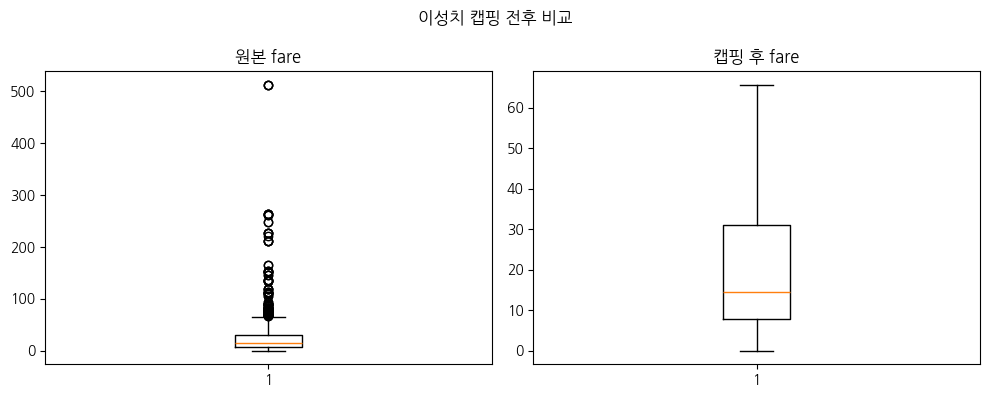

In [24]:
# 이상치를 제거하지 않고 경계값으로 대체, 데이터 수(891행) 유지
titanic_clipped = titanic_clean.copy()
titanic_clipped['Fare_clipped'] = titanic_clipped['Fare'].clip(
    lower = max(lower_bound, 0), #lower_bound(-26.7)와 0 중 큰 값 선택
    upper=upper_bound
) # clip(): 범위 밖의 값을 경계값으로 강제 변환

# 결과 확인
print('캡핑 전 최대값:', titanic_clean['Fare'].max())
print('캡핑 후 최대값:', titanic_clipped['Fare_clipped'].max())
print('행 수 변화 없음:', len(titanic_clipped))

# 전후 비교 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(titanic_clean['Fare'])
axes[0].set_title('원본 fare')
axes[1].boxplot(titanic_clipped['Fare_clipped'])
axes[1].set_title('캡핑 후 fare')

plt.suptitle('이성치 캡핑 전후 비교')
plt.tight_layout()
plt.show()

### 정규분포 확인 방법

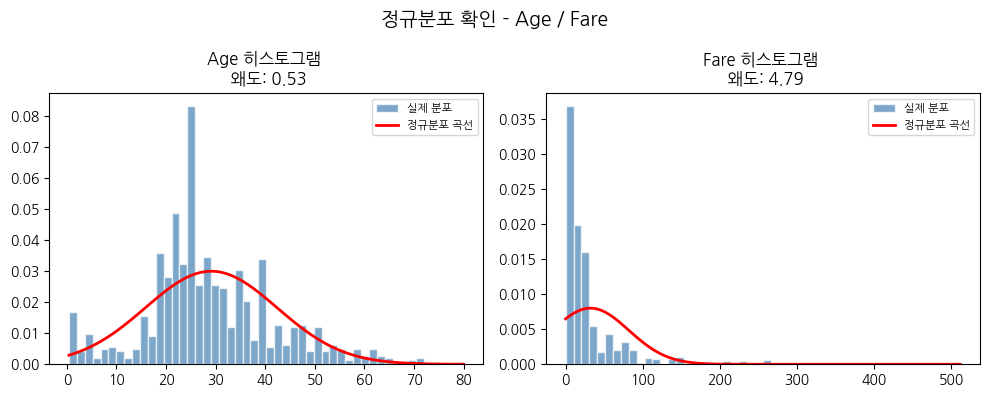

In [33]:
# 정규분포 확인을 위한 시각화
fig, axes = plt.subplots(1, 2, figsize=(10,4))
fig.suptitle('정규분포 확인 - Age / Fare', fontsize=14)

cols = ['Age', 'Fare']

for i, col in enumerate(cols):
    data = titanic_clean[col].dropna()
    # 히스토그램 + 정규분포 곡선
    ax1 = axes[i] # density=True로 y축을 밀도(확률)로 변환해 정규분포 곡선과 겹쳐 비교 가능
    ax1.hist(data, bins=50, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='실제 분포')
    # 정규분포 곡선 그리기
    x = np.linspace(data.min(), data.max(), 100) # 데이터 최소~최대 범위에서 100개 균등 간격 x값 생성
    ax1.plot(x, stats.norm.pdf(x, data.mean(), data.std()),color='red', linewidth=2, label='정규분포 곡선')
    ax1.set_title(f'{col} 히스토그램 \n 왜도: {data.skew():.2f}') # 왜도가 -1~1 사이면 정규분포에 가까움
    ax1.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 실습 7. 이상치 처리 -- 로그 변환

* np.log1p()는 log(1+x)를 계산해 주는 넘파이(NumPy)함수
* "데이터가 한쪽으로 크게 치우쳐 있을 대(양의 왜도)" 이를 정규분포 형태로 변환하기 위해 사용
* 모든 데이터에 1을 더한 뒤 로그를 취하면, 0이었던 데이터는 log(1) = 0이 되어 안전하게 변환
* 1p는 plus 1을 의미
* 값이 너무 큰 데이터(이상치)의 수치를 압축

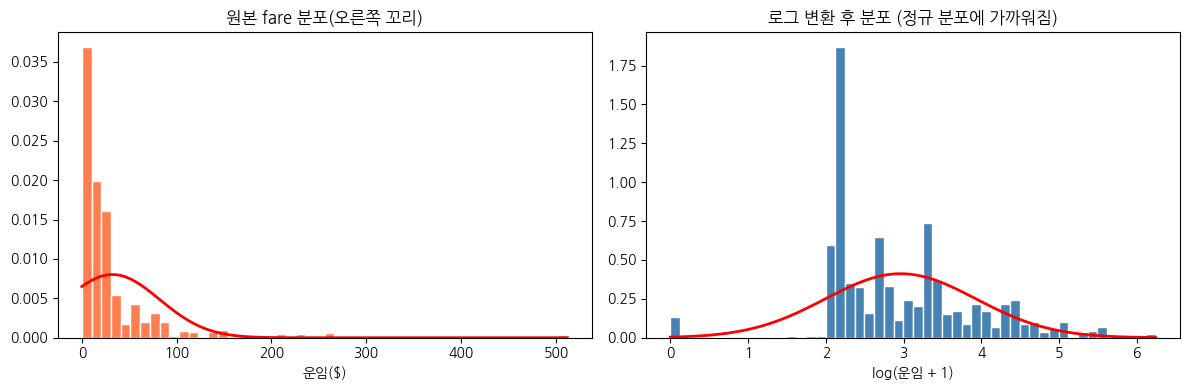

원본 fare 왜도: 4.79
로그 변환 후 왜도: 0.39


In [37]:
# 로그 변환
# 오른쪽으로 긴 꼬리(right-skewed) 분포를 로그 변환으로 정규분포에 가깝게 변환
titanic_log = titanic_clean.copy()
# log(0)은 정의 불가, x=0일 때도 log(1)=0으로 안전하게 처리
titanic_log['Fare_log'] = np.log1p(titanic_clean['Fare']) # 각 운임값에 log(1+x) 변환 적용

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(titanic_clean['Fare'], density=True, bins=50, color='coral', edgecolor='white')
x = np.linspace(titanic_clean['Fare'].min(), titanic_clean['Fare'].max(), 100)
axes[0].plot(x, stats.norm.pdf(x, titanic_clean['Fare'].mean(), titanic_clean['Fare'].std()),
             color='red', linewidth=2)
axes[0].set_title('원본 fare 분포(오른쪽 꼬리)')
axes[0].set_xlabel('운임($)')

axes[1].hist(titanic_log['Fare_log'], density=True, bins=50, color='steelblue', edgecolor='white')
x = np.linspace(titanic_log['Fare_log'].min(), titanic_log['Fare_log'].max(), 100)
# stats.norm.pdf(x, y) 는 x 값 데이터의 평균과 표준편차를 가진 정규분포에 해당하는 y값 계
axes[1].plot(x, stats.norm.pdf(x, titanic_log['Fare_log'].mean(), titanic_log['Fare_log'].std()),
             color='red', linewidth=2)
axes[1].set_title('로그 변환 후 분포 (정규 분포에 가까워짐)')
axes[1].set_xlabel('log(운임 + 1)')

plt.tight_layout()
plt.show()

# 왜도(skewness) 비교: 왜도가 0에 가까울수록 대칭적(정규분포에 가까움)
print(f"원본 fare 왜도: {titanic_clean['Fare'].skew():.2f}")
print(f"로그 변환 후 왜도: {titanic_log['Fare_log'].skew():.2f}")

### 실습 8. 다변수 이상치 탐지(나이 + 운임)

다변수 이상치: 5개
       Age      Fare     Age_z    Fare_z
195  58.00  146.5208  2.172495  2.301729
268  58.00  153.4625  2.172495  2.441498
297   2.00  151.5500 -2.038995  2.402990
305   0.92  151.5500 -2.120216  2.402990
438  64.00  263.0000  2.623727  4.647001


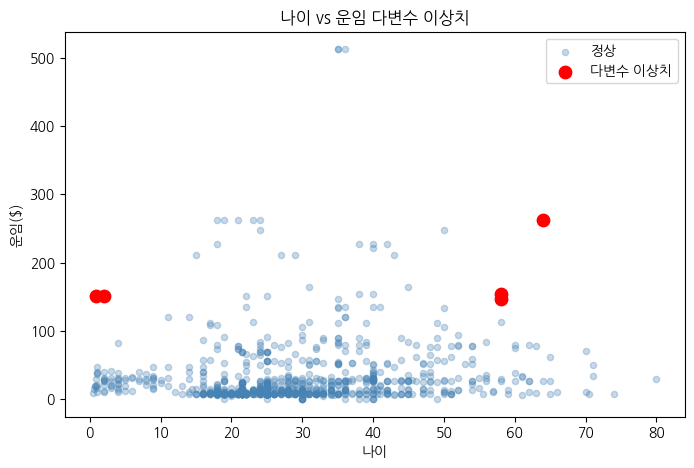

In [39]:
# 다변수 이상치 탐지: 단일 변수로는 정상이지만 조합이 이상한 경우
# 예: 나이 1살인데 운임 500달러 -> Age 단독 OK, Fare 단독 OK, 하지만 조합이 이상함

titanic_bivar = titanic_clean[['Age', 'Fare']].dropna().copy()

# 두 변수에 각각 Z-score 적용
titanic_bivar['Age_z'] = stats.zscore(titanic_bivar['Age'])
titanic_bivar['Fare_z'] = stats.zscore(titanic_bivar['Fare'])

# 두 변수 모두 |Z| > 2 를 다변수 이상치로 판단
both_extreme = (titanic_bivar['Age_z'].abs() > 2) & (titanic_bivar['Fare_z'].abs() > 2)

print(f"다변수 이상치: {both_extreme.sum()}개")
print(titanic_bivar[both_extreme]) # True에 해당하는 행 출력

# 산점도로 다변수 이상치 시각화
plt.figure(figsize=(8, 5))
normal = ~both_extreme
plt.scatter(titanic_bivar.loc[normal, 'Age'],
            titanic_bivar.loc[normal, 'Fare'],
            alpha=0.3, color='steelblue', label='정상', s=20)
plt.scatter(titanic_bivar.loc[both_extreme, 'Age'],
            titanic_bivar.loc[both_extreme, 'Fare'],
            color='red', label='다변수 이상치', s=80, zorder=5) #zorder=5 정상 점보다 위에 그려짐

plt.xlabel('나이')
plt.ylabel('운임($)')
plt.title('나이 vs 운임 다변수 이상치')
plt.legend()
plt.show()

### 실습 9. 종합 -- 처리 방법별 결과 비교

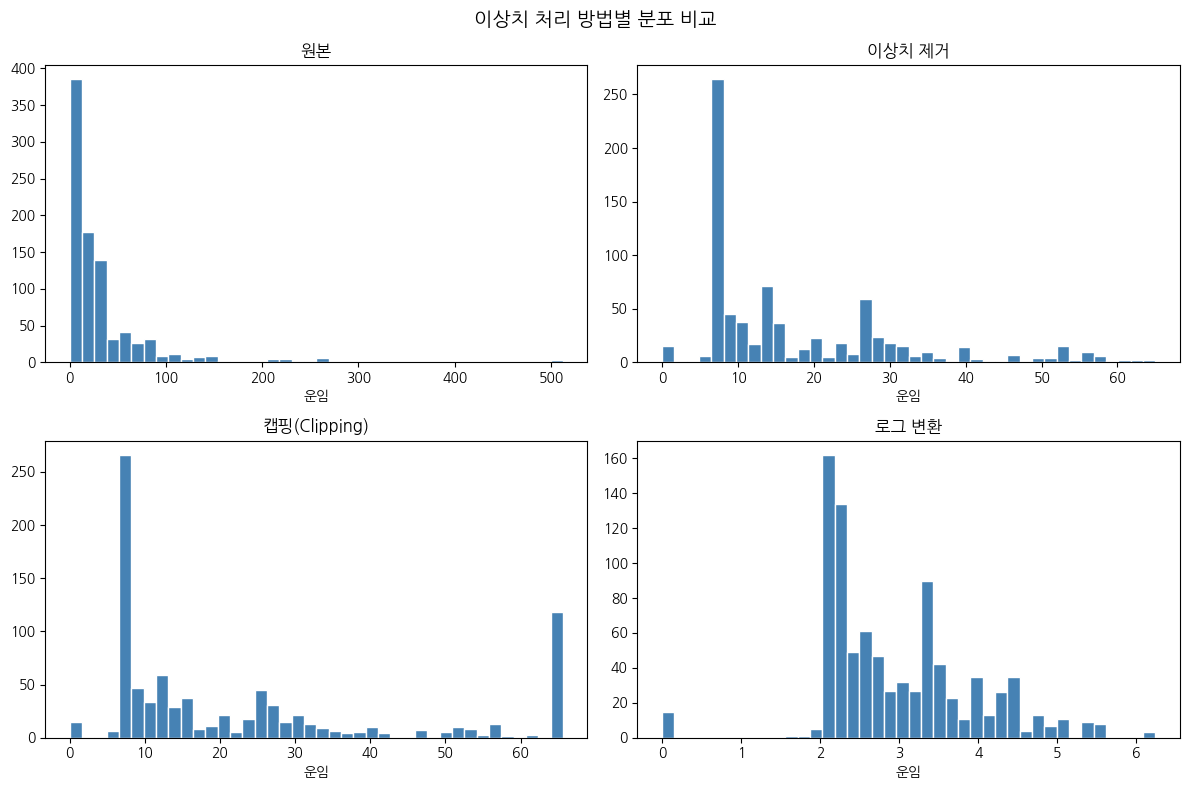

,원본,제거,캡핑,로그변환
count,891.00,775.00,891.00,891.00
mean,32.20,17.82,24.05,2.96
std,49.69,13.58,20.48,0.97
min,0.00,0.00,0.00,0.00
25%,7.91,7.90,7.91,2.19
50%,14.45,13.00,14.45,2.74
75%,31.00,26.00,31.00,3.47
max,512.33,65.00,65.63,6.24


In [40]:
# 이상치 처리 4가지 방법을 한눈에 비교
fare_original = titanic_clean['Fare']

# 방법 2: 이상치 제거 (행 수 줄어듬)
fare_dropped = titanic_clean.loc[~outlier_mask, 'Fare'] # 정상 데이터만 선택

# 방법 3: 캡핑 (이상치를 상한값으로 교체, 행 수 유지)
fare_clipped = titanic_clean['Fare'].clip(upper=upper_bound) # 상한을 초가한 값을 상한 값으로 대체

# 방법 4: 로그 변환 (분포 형태 자체를 변환 - 정규 분포와 비슷하게)
fare_log = np.log1p(titanic_clean['Fare']) # log(1+x) 변환으로 오른쪽 꼬리 분포를 정규분포에 가깝게 변환

fig, axes = plt.subplots(2, 2, figsize=(12, 8)) # 2행x2열
fig.suptitle('이상치 처리 방법별 분포 비교', fontsize=14)

for ax, data, title in zip(
    axes.flatten(), #2D 배열을 1D로 펼쳐 순서대로 순회 axes[0,1] -> axes[0]
    [fare_original, fare_dropped, fare_clipped, fare_log],
    ['원본', '이상치 제거', '캡핑(Clipping)', '로그 변환']
):
    ax.hist(data, bins=40, edgecolor='white', color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('운임')

plt.tight_layout()
plt.show()

# 방법별 요약 통계 비교표
summary = pd.DataFrame({
    '원본': fare_original.describe(),
    '제거': fare_dropped.describe(),
    '캡핑': fare_clipped.describe(),
    '로그변환': fare_log.describe()
}).round(2)
display(summary)